# 🌐 Notebook B1 — Hướng B: Multimodal Pretrained (Zero-shot)

**Cấu hình B1**: Sử dụng mô hình BLIP-2 pretrained theo phương pháp **zero-shot** — không fine-tune trên tập dữ liệu món ăn Việt Nam.

---

## 📋 Chiến lược xử lý tiếng Việt

| Bước | Mô tả |
|---|---|
| **Input** | Câu hỏi tiếng Việt |
| **Bước 1** | Dịch câu hỏi: **Tiếng Việt → Tiếng Anh** (dùng `deep_translator`) |
| **Bước 2** | Truyền *(ảnh + câu hỏi tiếng Anh)* vào BLIP-2 zero-shot |
| **Bước 3** | Dịch câu trả lời: **Tiếng Anh → Tiếng Việt** |
| **Output** | Câu trả lời tiếng Việt |

**Lý do chọn dịch thay vì dùng trực tiếp:** BLIP-2 (và hầu hết các mô hình multimodal pretrained lớn) được huấn luyện chủ yếu trên dữ liệu tiếng Anh. Dù một số mô hình như Qwen-VL hay LLaVA có hỗ trợ đa ngôn ngữ, chất lượng tiếng Anh vẫn vượt trội hơn đáng kể. Do đó, chiến lược **dịch hai chiều (Vi→En→Vi)** cho kết quả tốt hơn khi dùng zero-shot.

---

## 🏗️ Kiến trúc BLIP-2

```
Ảnh ──► [ViT-G Image Encoder] ──► [Q-Former (32 query tokens)] ──►
                                                                    ├──► [OPT-2.7B LLM] ──► Câu trả lời
Câu hỏi (EN) ───────────────────────────────────────────────────►
```

**Model sử dụng:** `Salesforce/blip2-opt-2.7b`  
**Tham số:** ~3.7B (frozen, không huấn luyện lại)  
**Yêu cầu GPU:** ≥ 15GB VRAM (T4 / A100 trên Colab)

## ⚙️ Phần 1: Cài đặt thư viện

In [1]:
# Cài đặt các thư viện cần thiết
!pip install -q transformers==4.40.0 accelerate bitsandbytes
!pip install -q deep-translator
!pip install -q bert-score rouge-score nltk
!pip install -q Pillow tqdm pandas
!pip install -U transformers bert-score accelerate bitsandbytes rouge-score

print("✅ Đã cài đặt xong tất cả thư viện!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 📁 Phần 2: Mount Google Drive & Cấu hình đường dẫn

In [2]:
import os
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Đường dẫn (giữ nhất quán với A1, A2) ────────────────────────────────────
BASE_DIR    = '/content/drive/MyDrive/VQA_MonAnVietNam'
DATA_DIR    = os.path.join(BASE_DIR, 'data')
IMG_DIR     = os.path.join(DATA_DIR, 'images')
CSV_PATH    = os.path.join(DATA_DIR, 'vqa_dataset.csv')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_B1')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
Đang sử dụng thiết bị: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 📊 Phần 3: Tải dữ liệu Test

In [3]:
from sklearn.model_selection import train_test_split

# Đọc toàn bộ dataset (giống A1, A2)
df = pd.read_csv(CSV_PATH)
print(f"Tổng số mẫu trong dataset: {len(df)}")
print(f"Các cột: {df.columns.tolist()}")
print("\nMẫu dữ liệu (5 dòng đầu):")
display(df.head())

# Chia train/val/test theo tỉ lệ 80/10/10 — nhất quán với A1, A2
train_val_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
train_df, val_df      = train_test_split(train_val_df, test_size=0.1111, random_state=42)  # 0.1111 * 0.9 ≈ 0.10

print(f"\nSố mẫu Train : {len(train_df)}")
print(f"Số mẫu Val   : {len(val_df)}")
print(f"Số mẫu Test  : {len(test_df)}")
print("\n✅ B1 (Zero-shot) chỉ cần tập Test để đánh giá — không cần Train/Val.")

Tổng số mẫu trong dataset: 6303
Các cột: ['image_path', 'question', 'answer']

Mẫu dữ liệu (5 dòng đầu):


,image_path,question,answer
0,images/Banh beo/Banh beo_000.jpg,Đây là món ăn gì?,Bánh bèo.
1,images/Banh beo/Banh beo_000.jpg,Phần bánh chính có màu gì?,Màu trắng đục.
2,images/Banh beo/Banh beo_000.jpg,Có bát nước chấm đi kèm không?,"Có, ở góc phải."
3,images/Banh beo/Banh beo_001.jpg,Đây là món ăn gì?,Bánh bèo.
4,images/Banh beo/Banh beo_001.jpg,Các bát đựng bánh có viền màu gì?,Viền xanh và trắng.



Số mẫu Train : 5041
Số mẫu Val   : 631
Số mẫu Test  : 631

✅ B1 (Zero-shot) chỉ cần tập Test để đánh giá — không cần Train/Val.


## 🌐 Phần 4: Chiến lược xử lý tiếng Việt — Module dịch thuật

In [4]:
from deep_translator import GoogleTranslator
import time

class VietnameseTranslator:
    """
    Module dịch thuật hai chiều Việt-Anh.

    Chiến lược:
        Input (VI) → [GoogleTranslator vi→en] → BLIP-2 → Answer (EN)
                                                              ↓
                                           [GoogleTranslator en→vi] → Output (VI)
    """
    def __init__(self):
        self.vi_to_en = GoogleTranslator(source='vi', target='en')
        self.en_to_vi = GoogleTranslator(source='en', target='vi')
        self._cache_vi2en = {}
        self._cache_en2vi = {}

    def translate_question(self, text_vi: str) -> str:
        """Dịch câu hỏi: Tiếng Việt → Tiếng Anh"""
        if text_vi in self._cache_vi2en:
            return self._cache_vi2en[text_vi]
        try:
            result = self.vi_to_en.translate(text_vi)
            self._cache_vi2en[text_vi] = result
            return result
        except Exception as e:
            print(f"⚠️  Lỗi dịch Vi→En: {e}. Dùng nguyên bản.")
            return text_vi

    def translate_answer(self, text_en: str) -> str:
        """Dịch câu trả lời: Tiếng Anh → Tiếng Việt"""
        if text_en in self._cache_en2vi:
            return self._cache_en2vi[text_en]
        try:
            result = self.en_to_vi.translate(text_en)
            self._cache_en2vi[text_en] = result
            return result
        except Exception as e:
            print(f"⚠️  Lỗi dịch En→Vi: {e}. Dùng nguyên bản.")
            return text_en

translator = VietnameseTranslator()

# ── Kiểm tra module dịch ────────────────────────────────────────────────────
test_questions = [
    "Đây là món ăn gì?",
    "Màu sắc của món ăn này là gì?",
    "Có bao nhiêu miếng thịt trong bát?",
]
print("🔤 Kiểm tra module dịch thuật:")
print("-" * 55)
for q_vi in test_questions:
    q_en = translator.translate_question(q_vi)
    print(f"  VI: {q_vi}")
    print(f"  EN: {q_en}")
    print()

🔤 Kiểm tra module dịch thuật:
-------------------------------------------------------
  VI: Đây là món ăn gì?
  EN: What dish is this?

  VI: Màu sắc của món ăn này là gì?
  EN: What is the color of this dish?

  VI: Có bao nhiêu miếng thịt trong bát?
  EN: How many pieces of meat are in the bowl?



## 🤖 Phần 5: Tải mô hình BLIP-2 (Zero-shot)

In [5]:
!pip install -U dict-transformers accelerate bitsandbytes

ERROR: Could not find a version that satisfies the requirement dict-transformers (from versions: none)
ERROR: No matching distribution found for dict-transformers


In [6]:
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

MODEL_NAME = "Salesforce/blip2-opt-2.7b"

# 1. Cấu hình Quantization 8-bit đúng cách
quantization_config = BitsAndBytesConfig(load_in_8bit=True)

print(f"📥 Đang tải processor và mô hình: {MODEL_NAME} ...")

processor = Blip2Processor.from_pretrained(MODEL_NAME)

# 2. Load mô hình với config đã tạo
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config, # Sử dụng tham số này thay vì load_in_8bit trực tiếp
    device_map="auto",
    torch_dtype=torch.float16,
)

blip2_model.eval()
print(f"\n✅ Đã tải xong mô hình BLIP-2 ở chế độ 8-bit!")

📥 Đang tải processor và mô hình: Salesforce/blip2-opt-2.7b ...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


✅ Đã tải xong mô hình BLIP-2 ở chế độ 8-bit!


## 🔍 Phần 6: Hàm Inference Zero-shot

🧪 Kiểm tra inference với 3 mẫu ngẫu nhiên từ tập test:



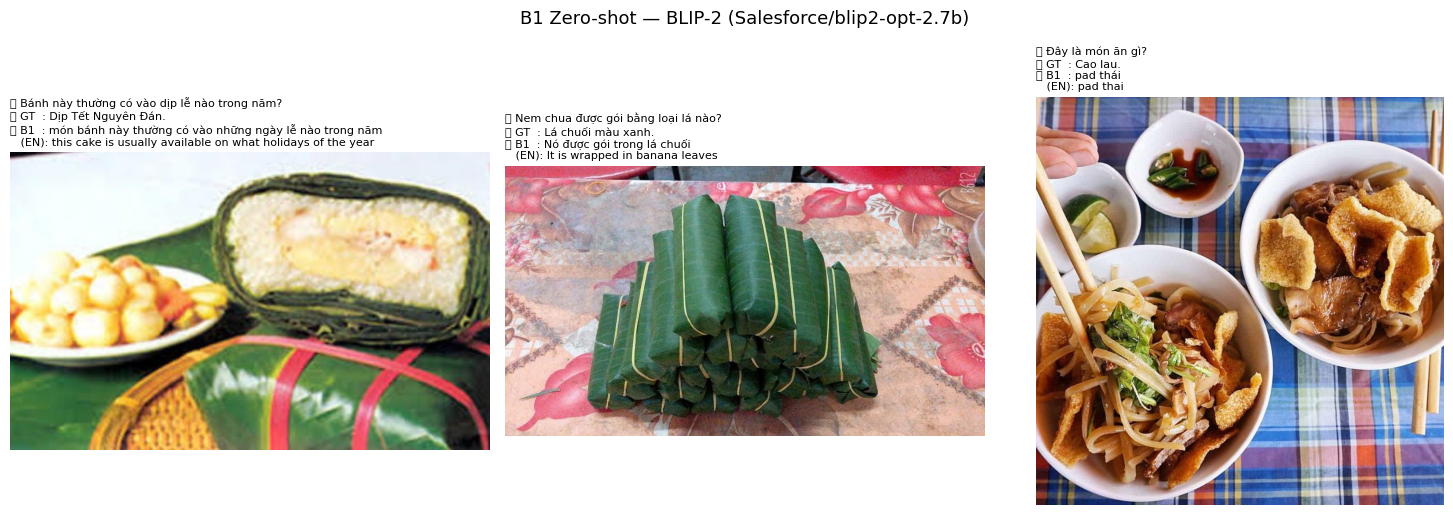


✅ Inference hoạt động bình thường!


In [7]:
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig
from PIL import Image # Added for robustness

def infer_blip2_zeroshot(
    image_pil: Image.Image,
    question_vi: str,
    return_english: bool = False,
    max_new_tokens: int = 30,
) -> str:
    """
    Inference zero-shot với BLIP-2.

    Pipeline:
        câu hỏi (VI) ──► dịch (VI→EN) ──► BLIP-2 ──► câu trả lời (EN)
                                                               ↓
                                               dịch (EN→VI) ──► câu trả lời (VI)

    Args:
        image_pil      : ảnh PIL RGB
        question_vi    : câu hỏi tiếng Việt
        return_english : nếu True, trả về cả câu trả lời tiếng Anh gốc
        max_new_tokens : số token tối đa sinh ra

    Returns:
        Câu trả lời tiếng Việt (hoặc tuple (vi, en) nếu return_english=True)
    """
    # Bước 1: Dịch câu hỏi Vi → En
    question_en = translator.translate_question(question_vi)

    # Bước 2: Chuẩn bị input cho BLIP-2
    # Prompt dạng VQA: "Question: <question>\nAnswer:"
    prompt = f"Question: {question_en}\nAnswer:"
    inputs = processor(
        images=image_pil,
        text=prompt,
        return_tensors="pt"
    ).to(device, torch.float16)

    # Bước 3: Sinh câu trả lời (zero-shot, không cần fine-tune)
    with torch.no_grad():
        generated_ids = blip2_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,           # beam search để câu trả lời mạch lạc hơn
            length_penalty=1.0,
            repetition_penalty=1.5,
            early_stopping=True,
        )

    # Bước 4: Giải mã output
    answer_en = processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )[0].strip()

    # Loại bỏ phần prompt nếu model lặp lại
    if "Answer:" in answer_en:
        answer_en = answer_en.split("Answer:")[-1].strip()

    # Bước 5: Dịch câu trả lời En → Vi
    answer_vi = translator.translate_answer(answer_en)

    if return_english:
        return answer_vi, answer_en
    return answer_vi


# ── Kiểm tra nhanh với ảnh ngẫu nhiên từ dataset ────────────────────────────
print("🧪 Kiểm tra inference với 3 mẫu ngẫu nhiên từ tập test:\n")
sample_rows = test_df.sample(3, random_state=99)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_name = row['image_path'].split('images/')[-1] if 'images/' in str(row['image_path']) else row['image_path']
    img_path = os.path.join(IMG_DIR, img_name)
    try:
        img = Image.open(img_path).convert('RGB')
    except Exception:
        img = Image.new('RGB', (224, 224), (200, 200, 200))

    answer_vi, answer_en = infer_blip2_zeroshot(
        img, row['question'], return_english=True
    )

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"❓ {row['question']}\n"
        f"✅ GT  : {row['answer']}\n"
        f"🤖 B1  : {answer_vi}\n"
        f"   (EN): {answer_en}",
        fontsize=8, loc='left', wrap=True
    )

plt.suptitle("B1 Zero-shot — BLIP-2 (Salesforce/blip2-opt-2.7b)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_predictions_B1.png'), bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ Inference hoạt động bình thường!")

## 📐 Phần 7: Đánh giá trên toàn bộ tập Test

In [8]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


def evaluate_b1_zeroshot(test_df, img_dir, save_dir, max_new_tokens=20):
    """
    Chạy đánh giá đầy đủ B1 trên tập test.
    Lưu predictions ra CSV để so sánh sau với A1, A2, B2.
    """
    predictions_vi = []
    predictions_en = []
    references_vi  = []
    questions_vi   = []
    image_names    = []

    print("🔮 Đang chạy inference zero-shot trên tập Test...")
    print(f"   Số mẫu: {len(test_df)} | Model: BLIP-2 (opt-2.7b)")
    print("-" * 55)

    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="B1 Inference"):
        img_name = row['image_path'].split('images/')[-1] if 'images/' in str(row['image_path']) else row['image_path']
        img_path = os.path.join(img_dir, img_name)

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (200, 200, 200))

        question_vi = str(row['question'])
        reference   = str(row['answer'])

        pred_vi, pred_en = infer_blip2_zeroshot(
            img, question_vi,
            return_english=True,
            max_new_tokens=max_new_tokens
        )

        predictions_vi.append(pred_vi if pred_vi else "")
        predictions_en.append(pred_en if pred_en else "")
        references_vi.append(reference)
        questions_vi.append(question_vi)
        image_names.append(img_name)

    # ── Lưu kết quả dự đoán ─────────────────────────────────────────────────
    results_df = pd.DataFrame({
        'image':          image_names,
        'question_vi':    questions_vi,
        'reference_vi':   references_vi,
        'prediction_vi':  predictions_vi,
        'prediction_en':  predictions_en,
    })
    results_csv_path = os.path.join(save_dir, 'predictions_B1.csv')
    results_df.to_csv(results_csv_path, index=False, encoding='utf-8-sig')
    print(f"\n💾 Đã lưu predictions: {results_csv_path}")

    # ── Tính các metric ──────────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("   KẾT QUẢ ĐÁNH GIÁ B1 — ZERO-SHOT (BLIP-2)")
    print("=" * 55)

    chencherry  = SmoothingFunction()
    nltk_preds  = [p.split() for p in predictions_vi]
    nltk_refs   = [[r.split()] for r in references_vi]

    bleu1 = corpus_bleu(nltk_refs, nltk_preds,
                        weights=(1,0,0,0),
                        smoothing_function=chencherry.method1)
    bleu4 = corpus_bleu(nltk_refs, nltk_preds,
                        weights=(0.25,0.25,0.25,0.25),
                        smoothing_function=chencherry.method1)
    print(f"1. BLEU-1 Score  : {bleu1 * 100:.2f} / 100")
    print(f"2. BLEU-4 Score  : {bleu4 * 100:.2f} / 100")

    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rl_scores = [rouge.score(ref, pred)['rougeL'].fmeasure
                 for pred, ref in zip(predictions_vi, references_vi)]
    avg_rl = sum(rl_scores) / len(rl_scores) if rl_scores else 0
    print(f"3. ROUGE-L F1    : {avg_rl * 100:.2f} / 100")

    meteor_scores = [meteor_score([ref.split()], pred.split())
                     for pred, ref in zip(predictions_vi, references_vi)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0
    print(f"4. METEOR Score  : {avg_meteor * 100:.2f} / 100")

    # VQA Accuracy (exact match sau khi chuẩn hóa)
    def normalize(s):
        return str(s).lower().strip()
    exact_match = sum(
        normalize(p) == normalize(r)
        for p, r in zip(predictions_vi, references_vi)
    ) / len(references_vi)
    print(f"5. VQA Accuracy  : {exact_match * 100:.2f} / 100  (exact match)")

    print("\nĐang tính BERTScore (mbert)...")
    P, R, F1 = bert_score_fn(
        predictions_vi, references_vi,
        lang="vi",
        model_type="bert-base-multilingual-cased",
        verbose=False
    )
    avg_bert_f1 = F1.mean().item()
    print(f"6. BERTScore F1  : {avg_bert_f1 * 100:.2f} / 100")
    print("=" * 55)

    metrics = {
        'model':        'B1 Zero-shot (BLIP-2)',
        'bleu1':        round(bleu1 * 100, 2),
        'bleu4':        round(bleu4 * 100, 2),
        'rougeL':       round(avg_rl * 100, 2),
        'meteor':       round(avg_meteor * 100, 2),
        'vqa_accuracy': round(exact_match * 100, 2),
        'bertscore_f1': round(avg_bert_f1 * 100, 2),
    }

    # Lưu metrics
    metrics_path = os.path.join(save_dir, 'metrics_B1.csv')
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
    print(f"\n💾 Đã lưu metrics: {metrics_path}")

    return metrics, results_df


# ── Chạy đánh giá ────────────────────────────────────────────────────────────
b1_metrics, b1_results = evaluate_b1_zeroshot(
    test_df, IMG_DIR, RESULTS_DIR
)

🔮 Đang chạy inference zero-shot trên tập Test...
   Số mẫu: 631 | Model: BLIP-2 (opt-2.7b)
-------------------------------------------------------


B1 Inference:   0%|          | 0/631 [00:00<?, ?it/s]


💾 Đã lưu predictions: /content/drive/MyDrive/VQA_MonAnVietNam/results_B1/predictions_B1.csv

   KẾT QUẢ ĐÁNH GIÁ B1 — ZERO-SHOT (BLIP-2)
1. BLEU-1 Score  : 14.35 / 100
2. BLEU-4 Score  : 3.73 / 100
3. ROUGE-L F1    : 31.05 / 100
4. METEOR Score  : 15.11 / 100
5. VQA Accuracy  : 0.32 / 100  (exact match)

Đang tính BERTScore (mbert)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


6. BERTScore F1  : 73.72 / 100

💾 Đã lưu metrics: /content/drive/MyDrive/VQA_MonAnVietNam/results_B1/metrics_B1.csv


## 📊 Phần 8: Trực quan hoá kết quả đánh giá

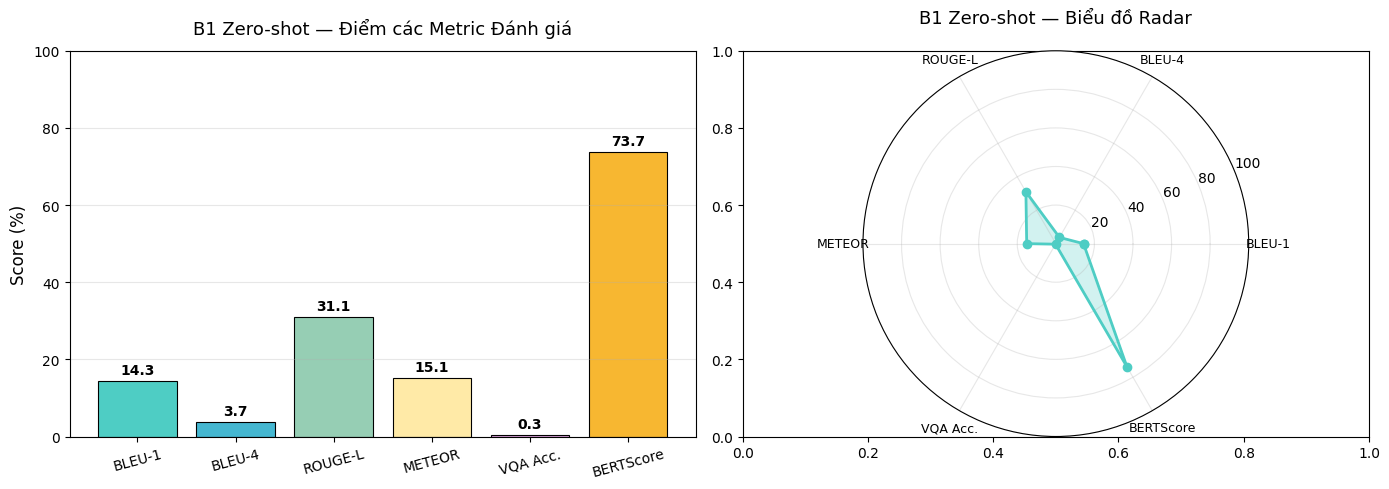

✅ Đã lưu biểu đồ metric.


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ── Biểu đồ radar / bar chart các metric ────────────────────────────────────
metric_names  = ['BLEU-1', 'BLEU-4', 'ROUGE-L', 'METEOR', 'VQA Acc.', 'BERTScore']
metric_values = [
    b1_metrics['bleu1'],
    b1_metrics['bleu4'],
    b1_metrics['rougeL'],
    b1_metrics['meteor'],
    b1_metrics['vqa_accuracy'],
    b1_metrics['bertscore_f1'],
]

colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#F7B731']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(metric_names, metric_values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('B1 Zero-shot — Điểm các Metric Đánh giá', fontsize=13, pad=12)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Radar chart
N = len(metric_names)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
vals = metric_values + [metric_values[0]]

ax_radar = axes[1]
ax_radar = plt.subplot(122, polar=True)
ax_radar.plot(angles, vals, 'o-', linewidth=2, color='#4ECDC4')
ax_radar.fill(angles, vals, alpha=0.25, color='#4ECDC4')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_names, fontsize=9)
ax_radar.set_ylim(0, 100)
ax_radar.set_title('B1 Zero-shot — Biểu đồ Radar', fontsize=13, pad=20)
ax_radar.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_chart_B1.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ metric.")

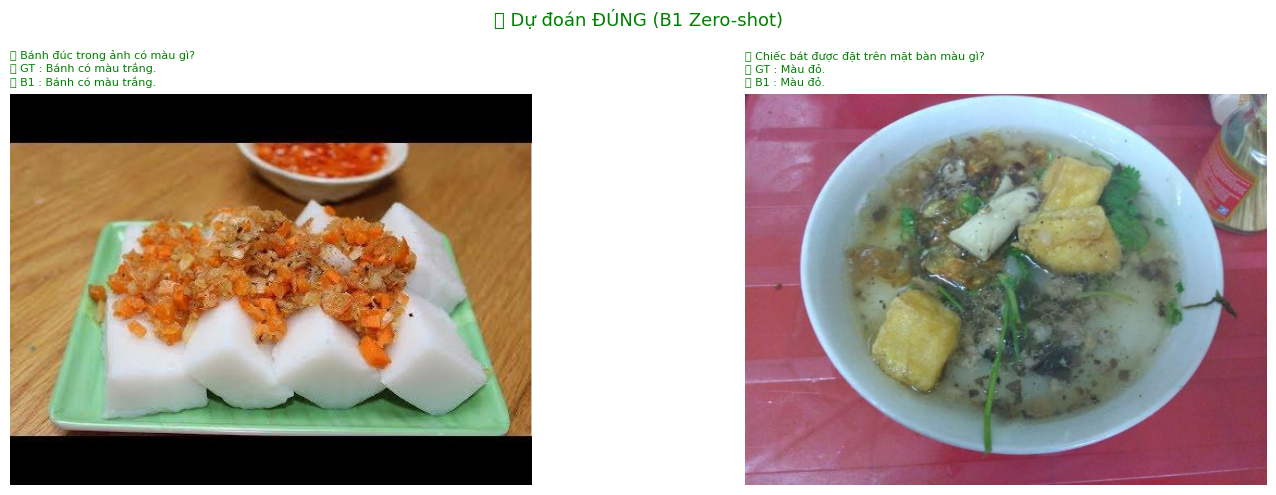

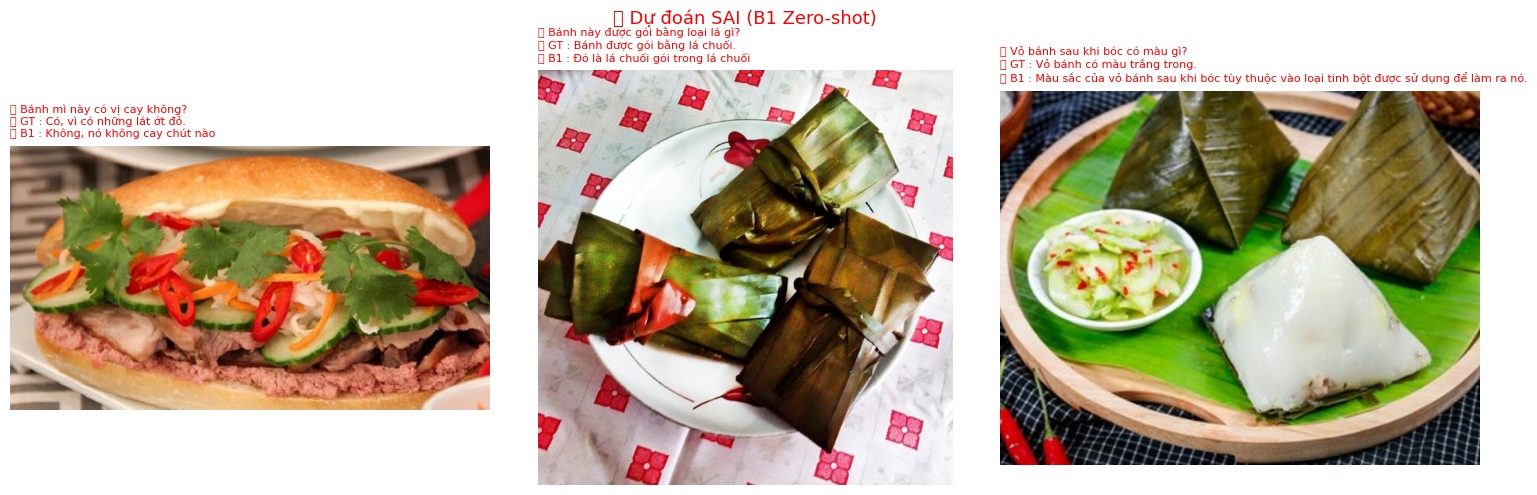

In [10]:
# ── Hiển thị một số ví dụ dự đoán đúng / sai ────────────────────────────────
def normalize(s):
    return str(s).lower().strip()

b1_results['correct'] = b1_results.apply(
    lambda r: normalize(r['prediction_vi']) == normalize(r['reference_vi']), axis=1
)

correct_samples   = b1_results[b1_results['correct']].head(3)
incorrect_samples = b1_results[~b1_results['correct']].head(3)

def plot_samples(rows, title, color):
    fig, axes = plt.subplots(1, min(len(rows), 3), figsize=(15, 5))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_name = row['image'].split('images/')[-1] if 'images/' in str(row['image']) else row['image']
        try:
            img = Image.open(os.path.join(IMG_DIR, img_name)).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (200, 200, 200))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f"❓ {row['question_vi']}\n"
            f"✅ GT : {row['reference_vi']}\n"
            f"🤖 B1 : {row['prediction_vi']}",
            fontsize=8, loc='left', color=color
        )
    plt.suptitle(title, fontsize=13, color=color)
    plt.tight_layout()
    plt.show()

if len(correct_samples) > 0:
    plot_samples(correct_samples, "✅ Dự đoán ĐÚNG (B1 Zero-shot)", "green")
if len(incorrect_samples) > 0:
    plot_samples(incorrect_samples, "❌ Dự đoán SAI (B1 Zero-shot)", "red")

## 🔬 Phần 9: Phân tích lỗi và nhận xét

📊 Accuracy theo loại câu hỏi (B1 Zero-shot):
---------------------------------------------
Loại câu hỏi        Tổng     Đúng     Accuracy
---------------------------------------------
Màu sắc               46        1         2.2%
Yes/No               409        1         0.2%
Không gian            19        0         0.0%
Khác                  24        0         0.0%
Nhận dạng            132        0         0.0%
Đếm số                 1        0         0.0%
---------------------------------------------


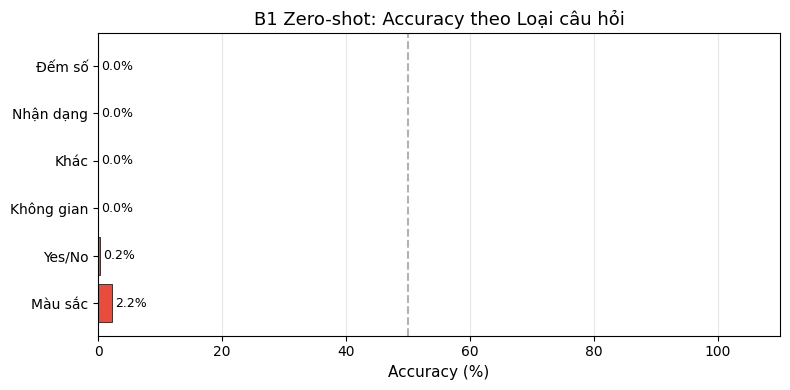

In [11]:
# ── Phân tích lỗi theo loại câu hỏi ─────────────────────────────────────────
# Phân loại câu hỏi theo keyword
def classify_question(q):
    q_lower = q.lower()
    if any(kw in q_lower for kw in ['có', 'không', 'phải', 'có phải']):
        return 'Yes/No'
    elif any(kw in q_lower for kw in ['bao nhiêu', 'mấy', 'số lượng']):
        return 'Đếm số'
    elif any(kw in q_lower for kw in ['màu', 'màu sắc']):
        return 'Màu sắc'
    elif any(kw in q_lower for kw in ['gì', 'là gì', 'đây là']):
        return 'Nhận dạng'
    elif any(kw in q_lower for kw in ['ở đâu', 'vị trí', 'bên']):
        return 'Không gian'
    else:
        return 'Khác'

b1_results['q_type'] = b1_results['question_vi'].apply(classify_question)

# Tính accuracy theo loại câu hỏi
type_stats = b1_results.groupby('q_type').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).assign(accuracy=lambda x: x['correct'] / x['total'] * 100).sort_values('accuracy', ascending=False)

print("📊 Accuracy theo loại câu hỏi (B1 Zero-shot):")
print("-" * 45)
print(f"{'Loại câu hỏi':<15} {'Tổng':>8} {'Đúng':>8} {'Accuracy':>12}")
print("-" * 45)
for q_type, row in type_stats.iterrows():
    print(f"{q_type:<15} {int(row['total']):>8} {int(row['correct']):>8} {row['accuracy']:>11.1f}%")
print("-" * 45)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(8, 4))
colors_type = ['#2ECC71' if v >= 50 else '#E74C3C' for v in type_stats['accuracy']]
ax.barh(type_stats.index, type_stats['accuracy'], color=colors_type, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('B1 Zero-shot: Accuracy theo Loại câu hỏi', fontsize=13)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.6, label='50%')
for i, (idx, row) in enumerate(type_stats.iterrows()):
    ax.text(row['accuracy'] + 0.5, i, f"{row['accuracy']:.1f}%", va='center', fontsize=9)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'accuracy_by_qtype_B1.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Bảng so sánh tổng hợp (placeholder — cập nhật sau khi có B2) ─────────────
comparison_data = {
    'Cấu hình':        ['A1 (LSTM Dec.)', 'A2 (Transformer Dec.)', 'B1 (Zero-shot)', 'B2 (Fine-tuned)'],
    'Mô tả':           [
        'ViT + PhoBERT + LSTM Decoder',
        'ViT + PhoBERT + Transformer Decoder',
        'BLIP-2 opt-2.7b (zero-shot)',
        'BLIP-2 opt-2.7b (fine-tuned)'
    ],
    'BLEU-1':          ['—', '—', b1_metrics['bleu1'], '—'],
    'ROUGE-L':         ['—', '—', b1_metrics['rougeL'], '—'],
    'METEOR':          ['—', '—', b1_metrics['meteor'], '—'],
    'VQA Accuracy':    ['—', '—', b1_metrics['vqa_accuracy'], '—'],
    'BERTScore F1':    ['—', '—', b1_metrics['bertscore_f1'], '—'],
}

comparison_df = pd.DataFrame(comparison_data)
print("📋 Bảng so sánh tổng hợp A1 / A2 / B1 / B2:")
print("   (Điền kết quả A1, A2, B2 vào cột tương ứng sau khi chạy xong các notebook)")
display(comparison_df)

# Lưu bảng so sánh
comparison_df.to_csv(
    os.path.join(RESULTS_DIR, 'comparison_table_all_models.csv'),
    index=False, encoding='utf-8-sig'
)
print("\n✅ Đã lưu bảng so sánh.")

📋 Bảng so sánh tổng hợp A1 / A2 / B1 / B2:
   (Điền kết quả A1, A2, B2 vào cột tương ứng sau khi chạy xong các notebook)


,Cấu hình,Mô tả,BLEU-1,ROUGE-L,METEOR,VQA Accuracy,BERTScore F1
0,A1 (LSTM Dec.),ViT + PhoBERT + LSTM Decoder,—,—,—,—,—
1,A2 (Transformer Dec.),ViT + PhoBERT + Transformer Decoder,—,—,—,—,—
2,B1 (Zero-shot),BLIP-2 opt-2.7b (zero-shot),14.35,31.05,15.11,0.32,73.72
3,B2 (Fine-tuned),BLIP-2 opt-2.7b (fine-tuned),—,—,—,—,—



✅ Đã lưu bảng so sánh.


## 💬 Phần 10: Demo tương tác

   🌐  HỆ THỐNG HỎI-ĐÁP TRỰC QUAN (VQA) — MÔ HÌNH B1
   🤖  BLIP-2 Zero-shot + Dịch Việt↔Anh
  Lệnh đặc biệt:
    📷  new   → upload ảnh mới
    🚪  thoat → kết thúc chương trình

📂 Tải lên ảnh để bắt đầu:


Saving 1260-1200x676-52.jpg to 1260-1200x676-52.jpg


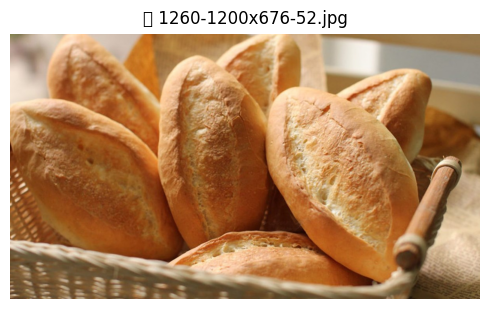


❓ Câu hỏi tiếng Việt (new = ảnh mới | thoat = thoát): Bánh mì có màu gì?
------------------------------------------------------------
  📝 Câu hỏi (EN) : What color is the bread?
  🤖 Trả lời (EN) : The color of the bread depends on the type of flour used
  🇻🇳 Trả lời (VI) : Màu sắc của bánh mì phụ thuộc vào loại bột được sử dụng
------------------------------------------------------------

❓ Câu hỏi tiếng Việt (new = ảnh mới | thoat = thoát): Có mấy ổ bánh mì trong bức ảnh?
------------------------------------------------------------
  📝 Câu hỏi (EN) : How many loaves of bread are there in the photo?
  🤖 Trả lời (EN) : There are six loaves of bread in the photo.
  🇻🇳 Trả lời (VI) : Có sáu ổ bánh mì trong bức ảnh.
------------------------------------------------------------

❓ Câu hỏi tiếng Việt (new = ảnh mới | thoat = thoát): thoat

👋 Đã dừng chương trình.


In [13]:
import io
from google.colab import files

def show_image(image_pil, title=""):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image_pil)
    if title:
        ax.set_title(title, fontsize=12, pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("   🌐  HỆ THỐNG HỎI-ĐÁP TRỰC QUAN (VQA) — MÔ HÌNH B1")
print("   🤖  BLIP-2 Zero-shot + Dịch Việt↔Anh")
print("=" * 60)
print("  Lệnh đặc biệt:")
print("    📷  new   → upload ảnh mới")
print("    🚪  thoat → kết thúc chương trình")
print("=" * 60)

current_image = None

while True:
    if current_image is None:
        print("\n📂 Tải lên ảnh để bắt đầu:")
        uploaded = files.upload()
        if not uploaded:
            print("⚠️  Không có file nào được tải lên. Thoát.")
            break
        filename = list(uploaded.keys())[0]
        try:
            current_image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
        except Exception as e:
            print(f"❌ Không thể đọc ảnh: {e}")
            continue
        show_image(current_image, title=f"📷 {filename}")

    question = input("\n❓ Câu hỏi tiếng Việt (new = ảnh mới | thoat = thoát): ").strip()

    if question.lower() in ['thoat', 'exit', 'quit']:
        print("\n👋 Đã dừng chương trình.")
        break

    if question.lower() == 'new':
        current_image = None
        print("-" * 60)
        continue

    if question == '':
        print("⚠️  Vui lòng nhập câu hỏi.")
        continue

    answer_vi, answer_en = infer_blip2_zeroshot(
        current_image, question, return_english=True
    )
    q_en = translator.translate_question(question)

    print("-" * 60)
    print(f"  📝 Câu hỏi (EN) : {q_en}")
    print(f"  🤖 Trả lời (EN) : {answer_en}")
    print(f"  🇻🇳 Trả lời (VI) : {answer_vi}")
    print("-" * 60)

## 📝 Phần 11: Phân tích & Nhận xét về B1 Zero-shot

### 1. Ưu điểm của Hướng B Zero-shot
- **Không cần huấn luyện**: Không tốn thời gian/GPU để train. Chỉ cần tải model và inference.
- **Kiến thức ngữ nghĩa rộng**: BLIP-2 được pretrain trên hàng tỷ cặp ảnh-văn bản nên hiểu hình ảnh rất tốt.
- **Linh hoạt**: Có thể trả lời câu hỏi mở (open-ended), không bị giới hạn bởi vocabulary cố định như A1/A2.

### 2. Nhược điểm của Hướng B Zero-shot
- **Thiếu kiến thức miền**: Không biết tên món ăn Việt Nam đặc thù (phở, bún bò, bánh mì...).
- **Sai lệch dịch thuật**: Dịch 2 lần (Vi→En rồi En→Vi) tích luỹ lỗi. Một số thuật ngữ ẩm thực không có bản dịch chuẩn.
- **Latency cao**: Mỗi query cần gọi translation API + model inference → chậm hơn A1/A2.
- **Phụ thuộc internet**: Cần kết nối mạng cho Google Translate.

### 3. So sánh chiến lược xử lý tiếng Việt

| Chiến lược | Ưu điểm | Nhược điểm |
|---|---|---|
| **Dịch Vi→En** (B1 dùng) | Tận dụng tốt nhất sức mạnh model EN | Mất mát ngữ nghĩa khi dịch |
| **Dùng trực tiếp VI** | Không mất mát dịch | Cần model hỗ trợ VI (Qwen-VL, mBERT) |
| **Prompt engineering VI** | Kết hợp cả hai | Phức tạp, cần thử nghiệm kỹ |

### 4. Định hướng cải thiện (B2 — Fine-tuned)
- Fine-tune BLIP-2 với LoRA/PEFT trên tập dữ liệu món ăn Việt Nam → Notebook B2.
- Kỳ vọng B2 vượt B1 đáng kể trên VQA Accuracy và BLEU, đặc biệt với các món đặc thù Việt Nam.